# Test ABL with K-epsilon model

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', './',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_keps as SANDwake3D

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
#?solve_ivp

## Set mesh and BC's 

In [3]:
# Set up mesh and BL parameters
Uinf = 1.0
nu   = 1.5E-5 # m^2/s

# y-z mesh 
#zmin = 1
#zmax = 120
#Nz   = int((zmax-zmin)/1.0+1)
zmin = 5
zmax = 200
Nz   = int((zmax-zmin)/5.0+1)
zvec = np.linspace(zmin,zmax,Nz)

Ny=51
ymax = 125
yvec = np.linspace(-ymax,ymax,Ny)

# x grid
xvecplot = [0, 10]

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')
print(ym.shape)

dy = 5.0
dz = 5.0
(51, 40)


In [5]:
# Set ABL parameters
ABLparam = {
    'ustar' : 0.4, #0.575652,
    'L' : float('inf'),
    'kappa' : 0.42,
    'rho' : 1.225,
    'z0' : 0.15,
    'Cmu' : 5.48**(-2),
}

# This parameter defines V(z) -- m/s per meter
veerpermeter = 0.0 #0.02

In [6]:
def tanhwake(y, z, zhh, turbR, delta, U1, U0=0):
    r = np.sqrt(y**2 + (z-zhh)**2)
    Ur = 0.5*(U1-U0)*(1.0 + np.tanh((r-turbR)/delta)) + U0
    return -Ur

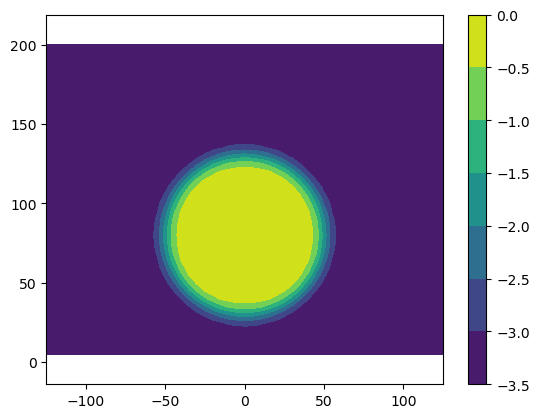

In [7]:
turbhh = 80
turbR  = 50
wakedef= 3.5
rdelta = 7.5 #10.0
wakeU  = wakedef*np.exp(-2.0*(ym**2 + (zm-turbhh)**2)/turbR**2)
wakeUr = tanhwake(ym, zm, turbhh, turbR, rdelta, wakedef)
plt.contourf(ym, zm, wakeUr)
plt.axis('equal')
plt.colorbar()

In [8]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,ABLparam)
    
# Set up veer profile
veerV = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerV[i] = veerpermeter*(z-turbhh)
    
# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, UABL), np.interp(zbot, zvec, UABL)
Vtop, Vbot = np.interp(ztop, zvec, veerV), np.interp(zbot, zvec, veerV)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi

Uhh, Vhh = np.interp(turbhh, zvec, UABL), np.interp(turbhh, zvec, UABL)
alpha = np.log(Utop/Ubot)/np.log(ztop/zbot)
print('Uhh = ',Uhh)
print('alpha = ',alpha)
print('rotor veer = ',Wdirtop-Wdirbot)

Uhh =  5.980139637675966
alpha =  0.1666205486623225
rotor veer =  0.0


In [9]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
Tinit  = np.ones((Ny, Nz))*300
EPSinit= np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = UABL[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = veerV[iz]
    Winit[:, iz] = 0.0
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam)*1.0 #0.2
    EPSinit[:, iz] = 5.0E-3 #9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    #EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,ABLparam)*0.50  #5.0E-4 is good
    
Uinit = Uinit - wakeUr
#for iy, y in enumerate(yvec):
#    Kinit[iy,:]   = SANDwake3D.set_k_init(zvec, dz, Uinit[0,:],ABLparam,k_factor=0.1)
#    EPSinit[iy,:] = SANDwake3D.set_e_init(zvec, dz, Uinit[0,:], Kinit[0,:], ABLparam)
#Kinit[:,0] = Kinit[:,1]
#Kinit[:,-2] = Kinit[:,-1]
#EPSinit[:,0] = EPSinit[:,1]
#EPSinit[:,-2] = EPSinit[:,-1]

phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['T'] = Tinit
phiinit['eps'] = EPSinit

(0.0, 200.0)

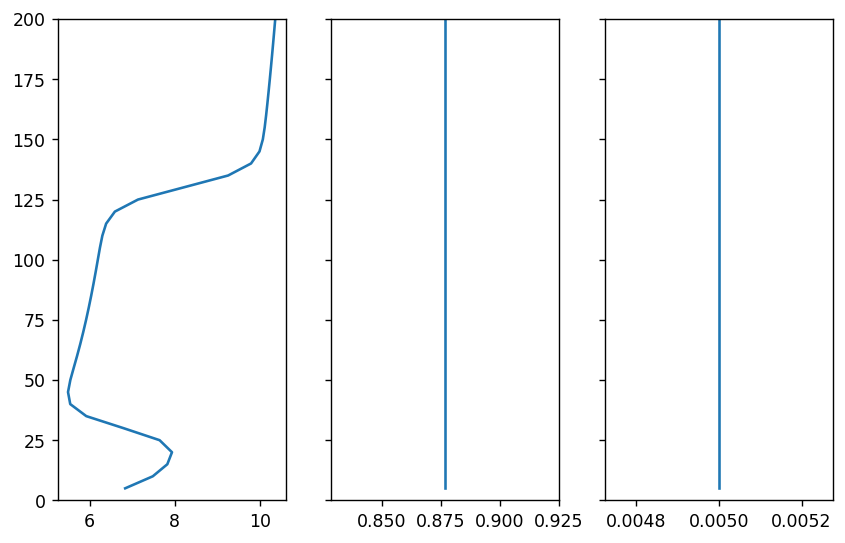

In [10]:
fig, axs = plt.subplots(1,3, sharey=True, dpi=125, figsize=(8,5))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Kinit[Ny//2,:], zvec)
axs[2].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

In [11]:
# Set boundary conditions
ubc = {}
ubc['ylo'] = {'type':'neumann', 'value':0.0}
ubc['yhi'] = {'type':'neumann', 'value':0.0}
ubc['zlo'] = {'type':'dirichlet', 'value':Uinit[0,0]}
ubc['zhi'] = {'type':'dirichlet', 'value':Uinit[0,-1]}

vbc = {}
vbc['ylo'] = {'type':'dirichlet', 'value':veerV}
vbc['yhi'] = {'type':'dirichlet', 'value':0.0}
vbc['zlo'] = {'type':'dirichlet', 'value':0.0}
vbc['zhi'] = {'type':'dirichlet', 'value':0.0}

wbc = {}
wbc['ylo'] = {'type':'neumann', 'value':0.0}
wbc['yhi'] = {'type':'neumann', 'value':0.0}
wbc['zlo'] = {'type':'dirichlet', 'value':0.0}
wbc['zhi'] = {'type':'neumann', 'value':0.0}

kbc = {}
kbc['ylo'] = {'type':'neumann', 'value':0.0}
kbc['yhi'] = {'type':'neumann', 'value':0.0}
kbc['zlo'] = {'type':'dirichlet', 'value':Kinit[0,0]}
kbc['zhi'] = {'type':'neumann', 'value':0.0}

epsbc = {}
epsbc['ylo'] = {'type':'neumann', 'value':0.0}
epsbc['yhi'] = {'type':'neumann', 'value':0.0}
epsbc['zlo'] = {'type':'dirichlet', 'value':EPSinit[0,0]}
epsbc['zhi'] = {'type':'neumann', 'value':0.0}

Tbc = {}
Tbc['ylo'] = {'type':'dirichlet', 'value':300}
Tbc['yhi'] = {'type':'dirichlet', 'value':300}
Tbc['zlo'] = {'type':'dirichlet', 'value':300}
Tbc['zhi'] = {'type':'dirichlet', 'value':300}

allbc = {'u':ubc, 'v':vbc, 'w':wbc, 'k':kbc, 'eps':epsbc, 'T':Tbc}

In [12]:
# Set parameters
params = {
    'nu' : nu,
    'Cmu' : 5.48**(-2),
    #'Cmu'  : 0.01,
    'C1eps' : 1.76,
    'C2eps' : 1.92,
    'C3eps' : 0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
    'sigmaT':1.0,
}
#params['nu']       = nu
#params['Cmu']      = 0.0
#params['C1eps']    = 0.0
#params['C2eps']    = 0.0
#params['C3eps']    = 0.0
#params['sigmak']   = 1.0
#params['sigmaeps'] = 1.0

In [13]:
xvecplot=[0, 200, 300, 400, 500] #[0, 100]#[0, 100, 200, 300]
dx  = 20 #25
#firstxvec = [xvecplot[0], xvecplot[0]+5, xvecplot[0]+10]
#xvec = np.concatenate((firstxvec, np.arange(firstxvec[-1]+dx, xvecplot[-1]+1.0E-6, dx)))

#xvec = [0, 10, 20, 30, 40]
xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec = [0, 10, 20]

#xvec = [0.0, 2.5, 5.0, 7.5, 10, 15, 20, 25, 30]
#xvec = np.arange(xvecplot[0], xvecplot[0]+dx+1.0E-6, dx)

#xvec = xvecplot
start_time = time.time()
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, allbc, SANDwake3D.kepsT_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=True, maxiter=100, tol=1.0E-4)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

x = 20.0 dx = 20.0
0 {'u': 3.5533467063799864, 'w': 0.0, 'k': 4.930556164717141, 'eps': 0.0504645112654564, 'T': 430.13751787748697, 'v': 0.0}
1 {'u': 0.21331639843038527, 'w': 0.0, 'k': 0.6678869394555096, 'eps': 0.0029230782684912, 'T': 0.625713233793709, 'v': 11.67640994121496}
2 {'u': 0.4956678853804555, 'w': 0.0, 'k': 0.22518940475630733, 'eps': 0.001740083221099967, 'T': 0.14148625499061934, 'v': 0.4241361353348928}
3 {'u': 0.029355865960341777, 'w': 0.0, 'k': 0.05956819681749524, 'eps': 0.000727646353344754, 'T': 0.005604325110868765, 'v': 1.3416650479556114}
4 {'u': 0.0647256377228826, 'w': 0.0, 'k': 0.009915592731466914, 'eps': 0.00016724416914427507, 'T': 0.0002153559319690962, 'v': 0.04116000780765734}
5 {'u': 0.0017641544073349004, 'w': 0.0, 'k': 0.005970585690955241, 'eps': 8.060821759371202e-05, 'T': 8.002388914161135e-06, 'v': 0.1246153288028424}
6 {'u': 0.004429869687182664, 'w': 0.0, 'k': 0.000476650435378658, 'eps': 1.0686274951565915e-05, 'T': 3.8118834041222805e-06,

5 {'u': 0.0033000017871993256, 'w': 0.0, 'k': 0.001640974373411129, 'eps': 2.4483915100313152e-05, 'T': 8.837497346825285e-07, 'v': 0.09473272303875628}
6 {'u': 0.0027557040100325975, 'w': 0.0, 'k': 0.0011337730159148966, 'eps': 1.6629931438411216e-05, 'T': 1.1350122933090388e-07, 'v': 0.009922669970835579}
7 {'u': 0.0003031567241551817, 'w': 0.0, 'k': 0.0001797232372325969, 'eps': 2.7126000085684465e-06, 'T': 1.106889972846777e-08, 'v': 0.008101716536499192}
8 {'u': 0.00023823853365504934, 'w': 0.0, 'k': 9.472186794359679e-05, 'eps': 1.381500761090324e-06, 'T': 7.373558292630799e-11, 'v': 0.0007751315429178976}
9 {'u': 2.134280180142325e-05, 'w': 0.0, 'k': 1.2109465573952856e-05, 'eps': 1.8171343469134254e-07, 'T': 8.763339923569057e-12, 'v': 0.0005832259415272087}
10 {'u': 1.5030645095499639e-05, 'w': 0.0, 'k': 6.728670365966277e-06, 'eps': 9.669830127901239e-08, 'T': 3.4796577094533783e-12, 'v': 5.9960532344284514e-05}
x = 120.0 dx = 20.0
0 {'u': 1.5720268993773832, 'w': 0.0, 'k': 0

4 {'u': 0.020257792377394473, 'w': 0.0, 'k': 0.008151880934406733, 'eps': 0.0001291858433250776, 'T': 1.2227885429994896e-05, 'v': 0.06218760316042443}
5 {'u': 0.0015485543013064632, 'w': 0.0, 'k': 0.0007872975708382083, 'eps': 1.2227242902311422e-05, 'T': 9.864656387345933e-08, 'v': 0.05573808803045859}
6 {'u': 0.0013460770787170216, 'w': 0.0, 'k': 0.0006709732038456267, 'eps': 1.0293121272888644e-05, 'T': 2.274133468571262e-08, 'v': 0.0049731388203234006}
7 {'u': 0.0001208627766772749, 'w': 0.0, 'k': 7.545001195536594e-05, 'eps': 1.2001584936608516e-06, 'T': 1.379172834367526e-09, 'v': 0.004227291896388907}
8 {'u': 9.934298974917892e-05, 'w': 0.0, 'k': 4.9521169079983564e-05, 'eps': 7.555348532608405e-07, 'T': 1.1411272093211742e-11, 'v': 0.00033305521240316257}
9 {'u': 7.10492254455668e-06, 'w': 0.0, 'k': 4.695147003595642e-06, 'eps': 7.42653580274224e-08, 'T': 3.176753851317462e-12, 'v': 0.0002636607867938103}
10 {'u': 5.355648621106444e-06, 'w': 0.0, 'k': 2.972319032419793e-06, 'e

3 {'u': 0.013322479692950332, 'w': 0.0, 'k': 0.004984024053696355, 'eps': 7.869202750448629e-05, 'T': 0.00023918463653731654, 'v': 0.43562516957651903}
4 {'u': 0.01231048415639664, 'w': 0.0, 'k': 0.005028739029529641, 'eps': 7.905050358762341e-05, 'T': 4.2861729522269556e-06, 'v': 0.03875857904110977}
5 {'u': 0.0008200060504981121, 'w': 0.0, 'k': 0.00044808006042571706, 'eps': 6.984736099243408e-06, 'T': 3.080729531746239e-08, 'v': 0.03503892004453687}
6 {'u': 0.0007250271845611035, 'w': 0.0, 'k': 0.00037207393928373656, 'eps': 5.661939203340274e-06, 'T': 6.467962116951961e-09, 'v': 0.0027558134904485864}
7 {'u': 5.641928321502739e-05, 'w': 0.0, 'k': 3.7170724734250584e-05, 'eps': 5.876235980639798e-07, 'T': 3.01778471849664e-10, 'v': 0.0023770892970760523}
8 {'u': 4.7473419804329765e-05, 'w': 0.0, 'k': 2.433522207560414e-05, 'eps': 3.6854050500648946e-07, 'T': 3.682558675960881e-12, 'v': 0.000161323719654667}
9 {'u': 2.8480903124555143e-06, 'w': 0.0, 'k': 2.027133625020033e-06, 'eps':

5 {'u': 0.0004500955259236314, 'w': 0.0, 'k': 0.00025373967027650976, 'eps': 3.874735526155748e-06, 'T': 1.5866926657901676e-08, 'v': 0.022357678334032485}
6 {'u': 0.00040478759430594776, 'w': 0.0, 'k': 0.00020380058782934135, 'eps': 3.020673538891219e-06, 'T': 2.5033387360125923e-09, 'v': 0.0015506325008368851}
7 {'u': 2.7580312130272973e-05, 'w': 0.0, 'k': 1.8707420877373343e-05, 'eps': 2.872178124846234e-07, 'T': 8.94559431982122e-11, 'v': 0.0013569685664132631}
8 {'u': 2.3768501264637115e-05, 'w': 0.0, 'k': 1.1835327585284002e-05, 'eps': 1.7463779377547883e-07, 'T': 3.1228979704343326e-12, 'v': 7.940045790209294e-05}
x = 420.0 dx = 20.0
0 {'u': 0.619104364735697, 'w': 0.0, 'k': 0.31159540554014514, 'eps': 0.004535240767662223, 'T': 0.020509446277237164, 'v': 2.657911838219591}
1 {'u': 0.07496159900709923, 'w': 0.0, 'k': 0.025194269246449737, 'eps': 0.0004068426809944919, 'T': 0.020372543211971957, 'v': 2.5334973015157614}
2 {'u': 0.07142064571622758, 'w': 0.0, 'k': 0.02279449439770

(5.0, 200.0)

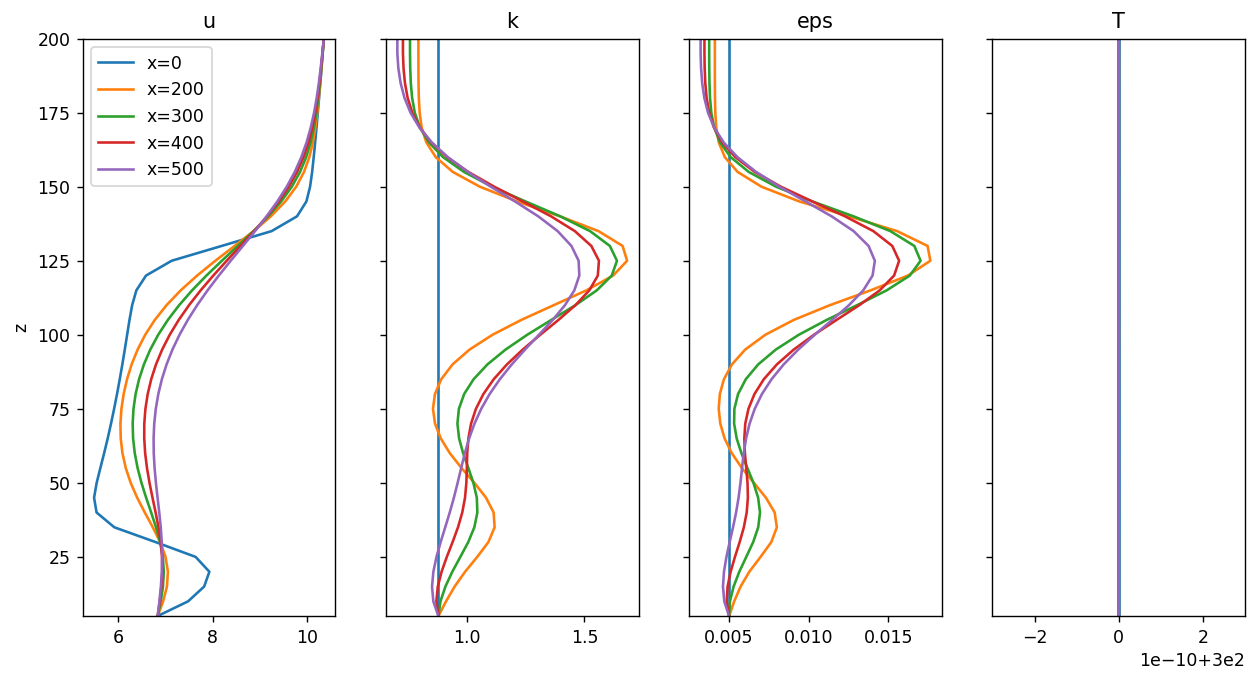

In [14]:
plotvars=['u', 'k', 'eps', 'T']
islice = Ny//2
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,6), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    #axs[iv].plot(np.mean(phi[v][0,:,:], axis=0), zvec,)
    #axs[iv].plot(np.mean(phi[v][-1,:,:], axis=0), zvec,)
    #axs[iv].plot(phi[v][0,islice,:], zvec,)
    #axs[iv].plot(phi[v][-1,islice,:], zvec,)    
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

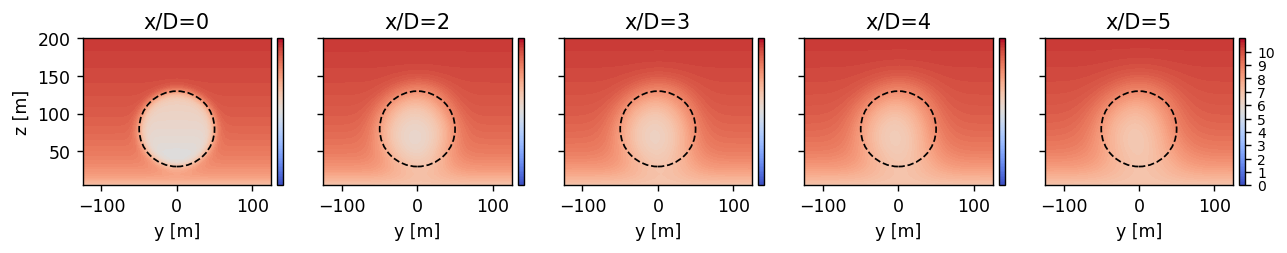

In [15]:
savefigs = False
cbarticks=np.arange(0,11,1)

fig, axs = plt.subplots(1, len(xvecplot), figsize=(12,3.25), dpi=125, sharey=True)
for ix, x in enumerate(xvecplot):
    ixRANS = find_nearest(xvec, x)
    c=axs[ix].contourf(ym, zm, phi['u'][ixRANS,:,:], levels=np.linspace(0,11,91), cmap='coolwarm')
    axs[ix].set_aspect('equal')
    axs[ix].set_title('x/D=%.0f'%(0.5*x/turbR))
    axs[ix].set_xlabel('y [m]')
    rotorcirc = plt.Circle((0.0, turbhh), turbR, color='k', linestyle='--', fill=False)
    axs[ix].add_patch(rotorcirc)
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    if ix < len(xvecplot)-1:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator([]))
    else:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax,ticks = matplotlib.ticker.FixedLocator(cbarticks))
        cbar.ax.tick_params(labelsize=8)
        
axs[0].set_ylabel('z [m]')

if savefigs:
    plt.tight_layout()
    plt.savefig('TestABL_KEPST.png')

In [16]:
print(phi['u'].shape)

(26, 51, 40)
